Импорт библиотек

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import plot_tree, export_text

import warnings
warnings.filterwarnings('ignore')

Загрузка данных

In [16]:
df = pd.read_csv('global_minimum_wage_processed.csv')
print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

Размер датасета: (186, 26)
Колонки: ['Country', 'Minimum_Wage_Local', 'Currency', 'Wage_Period', 'Minimum_Wage_USD_Monthly', 'Year', 'Notes', 'has_minimum_wage', 'currency_encoded', 'period_encoded', 'curr_AFN', 'curr_ALL', 'curr_AOA', 'curr_ARS', 'curr_DZD', 'curr_EUR', 'curr_USD', 'curr_XAF', 'curr_XCD', 'curr_XOF', 'period_Hourly', 'period_Monthly', 'period_Weekly', 'note_has_statutory', 'note_has_collective', 'note_has_sector']


Определение признаков и целевой переменной

In [17]:
target = 'Minimum_Wage_USD_Monthly'
exclude_cols = ['Country', 'Currency', 'Wage_Period', 'Notes', target]
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df[target]

print(f"Количество признаков: {X.shape[1]}")
print(f"Количество объектов: {X.shape[0]}")
print(f"Признаки: {feature_cols}")

Количество признаков: 21
Количество объектов: 186
Признаки: ['Minimum_Wage_Local', 'Year', 'has_minimum_wage', 'currency_encoded', 'period_encoded', 'curr_AFN', 'curr_ALL', 'curr_AOA', 'curr_ARS', 'curr_DZD', 'curr_EUR', 'curr_USD', 'curr_XAF', 'curr_XCD', 'curr_XOF', 'period_Hourly', 'period_Monthly', 'period_Weekly', 'note_has_statutory', 'note_has_collective', 'note_has_sector']


Удаление строк с пропусками в целевой переменной

In [18]:
mask = y.notna()
X = X[mask]
y = y[mask]
print(f"После удаления пропусков в целевой переменной: {X.shape[0]} объектов")

После удаления пропусков в целевой переменной: 186 объектов


 Заполнение пропусков в признаках

In [19]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=feature_cols)
print("Пропуски в признаках заполнены медианным значением")
print(f"Проверка на NaN: {X_imputed.isnull().sum().sum()}")

Пропуски в признаках заполнены медианным значением
Проверка на NaN: 0


Разделение на обучающую и тестовую выборки

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")

Обучающая выборка: 148 объектов
Тестовая выборка: 38 объектов


Масштабирование признаков

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование выполнено (StandardScaler)")
print(f"Проверка на NaN после масштабирования: {np.isnan(X_train_scaled).sum()}")

Масштабирование выполнено (StandardScaler)
Проверка на NaN после масштабирования: 0


Обучение линейной регрессии

In [22]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("ЛИНЕЙНАЯ РЕГРЕССИЯ")
print(f"RMSE: {rmse_lr:.2f} USD")
print(f"MAE: {mae_lr:.2f} USD")
print(f"R2: {r2_lr:.4f}")

ЛИНЕЙНАЯ РЕГРЕССИЯ
RMSE: 537.50 USD
MAE: 388.07 USD
R2: 0.3740


Обучение SVM

In [23]:
svm = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
mae_svm = mean_absolute_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("SVM")
print(f"RMSE: {rmse_svm:.2f} USD")
print(f"MAE: {mae_svm:.2f} USD")
print(f"R2: {r2_svm:.4f}")

SVM
RMSE: 754.94 USD
MAE: 433.32 USD
R2: -0.2349


Обучение дерева решений

In [24]:
dt = DecisionTreeRegressor(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("ДЕРЕВО РЕШЕНИЙ")
print(f"RMSE: {rmse_dt:.2f} USD")
print(f"MAE: {mae_dt:.2f} USD")
print(f"R2: {r2_dt:.4f}")

ДЕРЕВО РЕШЕНИЙ
RMSE: 531.56 USD
MAE: 288.91 USD
R2: 0.3878


Сравнение качества моделей

In [25]:
results = pd.DataFrame({
    'Модель': ['Линейная регрессия', 'SVM', 'Дерево решений'],
    'RMSE (USD)': [rmse_lr, rmse_svm, rmse_dt],
    'MAE (USD)': [mae_lr, mae_svm, mae_dt],
    'R2': [r2_lr, r2_svm, r2_dt]
})

print(results.to_string(index=False))

best_model = results.loc[results['R2'].idxmax(), 'Модель']
print(f"\nЛучшая модель по R2: {best_model}")

            Модель  RMSE (USD)  MAE (USD)        R2
Линейная регрессия  537.501212 388.071465  0.374040
               SVM  754.942112 433.320356 -0.234851
    Дерево решений  531.555045 288.907288  0.387813

Лучшая модель по R2: Дерево решений


Визуализация сравнения моделей

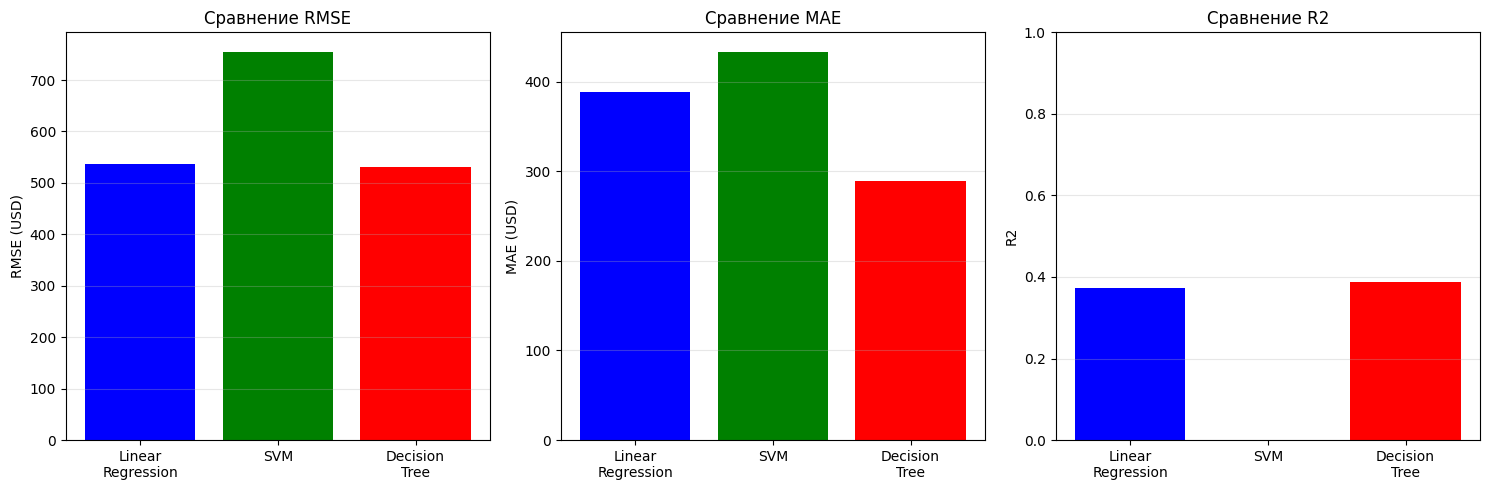

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_names = ['Linear\nRegression', 'SVM', 'Decision\nTree']
rmse_values = [rmse_lr, rmse_svm, rmse_dt]
mae_values = [mae_lr, mae_svm, mae_dt]
r2_values = [r2_lr, r2_svm, r2_dt]

axes[0].bar(models_names, rmse_values, color=['blue', 'green', 'red'])
axes[0].set_ylabel('RMSE (USD)')
axes[0].set_title('Сравнение RMSE')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(models_names, mae_values, color=['blue', 'green', 'red'])
axes[1].set_ylabel('MAE (USD)')
axes[1].set_title('Сравнение MAE')
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(models_names, r2_values, color=['blue', 'green', 'red'])
axes[2].set_ylabel('R2')
axes[2].set_title('Сравнение R2')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Важность признаков в дереве решений

In [27]:
feature_importance = pd.DataFrame({
    'Признак': feature_cols,
    'Важность': dt.feature_importances_
}).sort_values('Важность', ascending=False)

print("ВАЖНОСТЬ ПРИЗНАКОВ")
print(feature_importance)

ВАЖНОСТЬ ПРИЗНАКОВ
                Признак  Важность
10             curr_EUR  0.506178
0    Minimum_Wage_Local  0.254279
15        period_Hourly  0.085754
13             curr_XCD  0.077893
1                  Year  0.018562
3      currency_encoded  0.014797
18   note_has_statutory  0.013701
8              curr_ARS  0.013615
4        period_encoded  0.012640
2      has_minimum_wage  0.002580
7              curr_AOA  0.000000
6              curr_ALL  0.000000
5              curr_AFN  0.000000
12             curr_XAF  0.000000
11             curr_USD  0.000000
9              curr_DZD  0.000000
14             curr_XOF  0.000000
16       period_Monthly  0.000000
17        period_Weekly  0.000000
19  note_has_collective  0.000000
20      note_has_sector  0.000000


График важности признаков

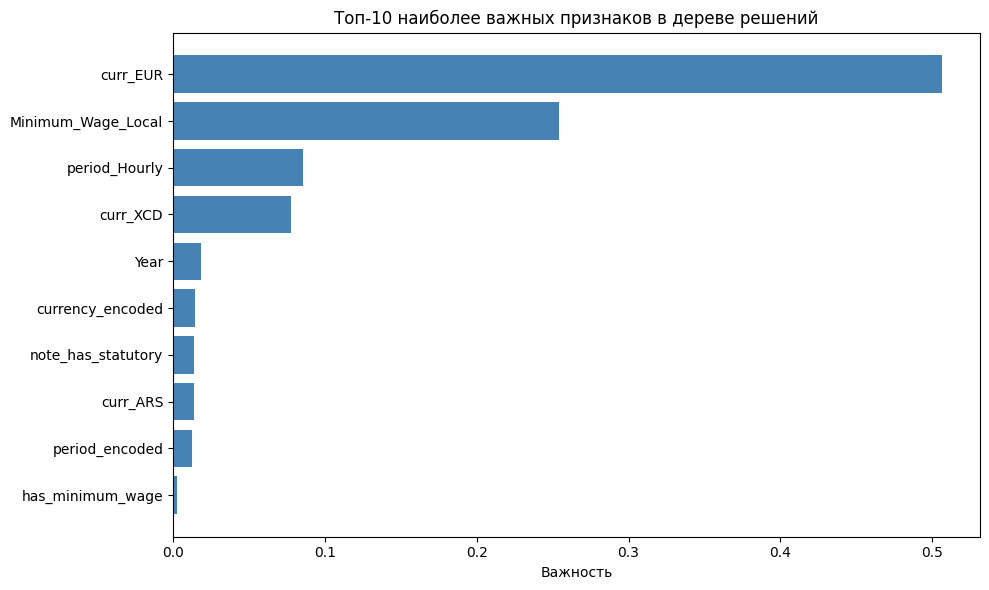

In [28]:
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Признак'], top_features['Важность'], color='steelblue')
plt.xlabel('Важность')
plt.title('Топ-10 наиболее важных признаков в дереве решений')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Визуализация дерева решений

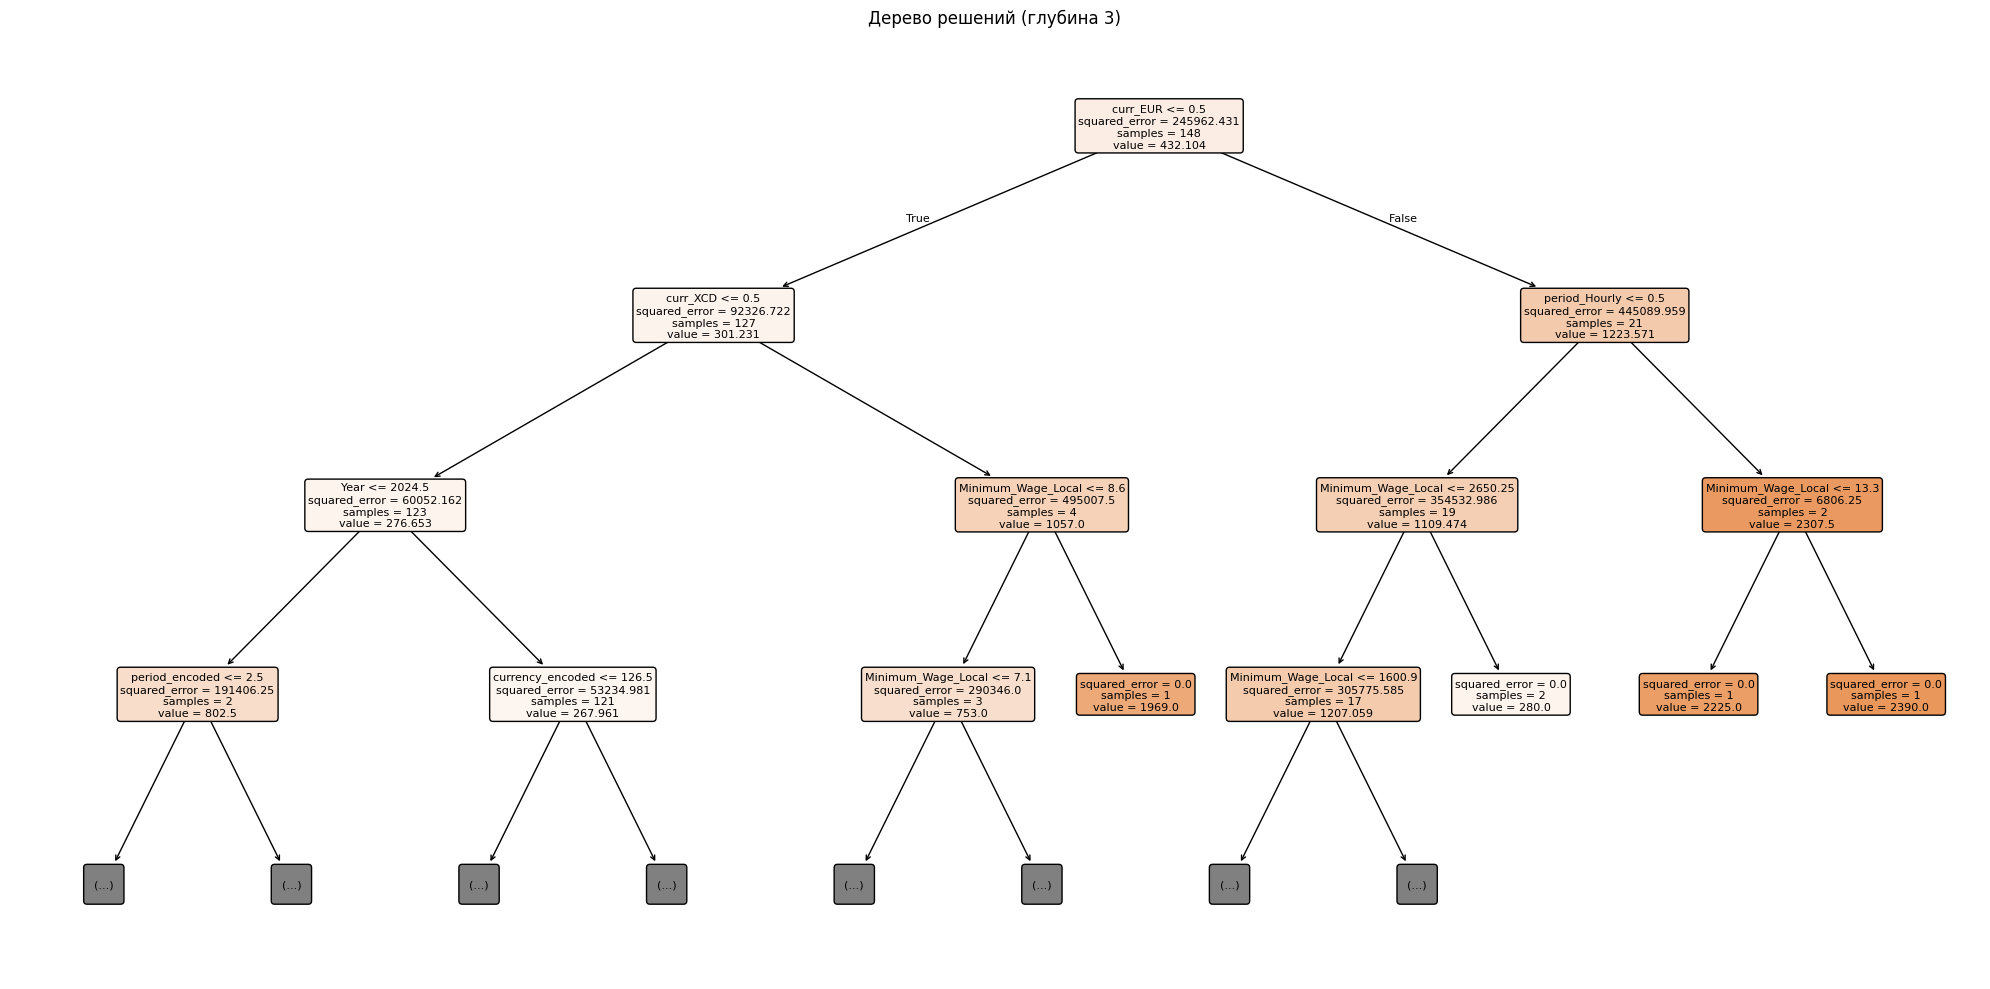

In [29]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title('Дерево решений (глубина 3)')
plt.tight_layout()
plt.show()

Текстовое представление правил дерева

In [30]:
from sklearn.tree import export_text

tree_rules = export_text(dt, feature_names=feature_cols, max_depth=3)
print("ПРАВИЛА ДЕРЕВА РЕШЕНИЙ (первые 3 уровня)")
print(tree_rules)

ПРАВИЛА ДЕРЕВА РЕШЕНИЙ (первые 3 уровня)
|--- curr_EUR <= 0.50
|   |--- curr_XCD <= 0.50
|   |   |--- Year <= 2024.50
|   |   |   |--- period_encoded <= 2.50
|   |   |   |   |--- value: [1240.00]
|   |   |   |--- period_encoded >  2.50
|   |   |   |   |--- value: [365.00]
|   |   |--- Year >  2024.50
|   |   |   |--- currency_encoded <= 126.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- currency_encoded >  126.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- curr_XCD >  0.50
|   |   |--- Minimum_Wage_Local <= 8.60
|   |   |   |--- Minimum_Wage_Local <= 7.10
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Minimum_Wage_Local >  7.10
|   |   |   |   |--- value: [36.00]
|   |   |--- Minimum_Wage_Local >  8.60
|   |   |   |--- value: [1969.00]
|--- curr_EUR >  0.50
|   |--- period_Hourly <= 0.50
|   |   |--- Minimum_Wage_Local <= 2650.25
|   |   |   |--- Minimum_Wage_Local <= 1600.90
|   |   |   |   |--- truncated branch of depth 2
|   |  

Итоговые выводы

In [32]:
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ ЛАБОРАТОРНОЙ РАБОТЫ")
print(f"1. Линейная регрессия: RMSE={rmse_lr:.1f}, R2={r2_lr:.3f}")
print(f"2. SVM: RMSE={rmse_svm:.1f}, R2={r2_svm:.3f}")
print(f"3. Дерево решений: RMSE={rmse_dt:.1f}, R2={r2_dt:.3f}")
print(f"4. Наиболее важный признак: {feature_importance.iloc[0, 0]}")

ВЫВОДЫ ПО РЕЗУЛЬТАТАМ ЛАБОРАТОРНОЙ РАБОТЫ
1. Линейная регрессия: RMSE=537.5, R2=0.374
2. SVM: RMSE=754.9, R2=-0.235
3. Дерево решений: RMSE=531.6, R2=0.388
4. Наиболее важный признак: curr_EUR
